# 10年定着予測 - Baseline LightGBM with Feature Engineering

**目的**: EDAレポート（data_exploration_report.md）で提案された全ての特徴量エンジニアリング手法を実装し、LightGBMベースラインモデルを構築する。

## 実装する特徴量

### 1. 月次データの集約特徴量
- 統計量ベース（mean, std, min, max, median, cv）
- 時期別統計量（初期3ヶ月、中期、後期、差分）
- トレンド特徴量（線形回帰の傾き、差、比率）

### 2. カテゴリカル変数の処理
- One-Hot Encoding
- Target Encoding（CVでリーク防止）
- 順序エンコーディング

### 3. テキストデータの特徴抽出
- TF-IDF特徴量
- テキスト統計量（文字数、単語数など）

### 4. 月次カテゴリカル変数の変化パターン
- 部署異動、職種変更、役割変更、等級変更、勤務地変更、上司変更

### 5. 交互作用特徴量
- 年齢×前職経験、初任給×初期等級、残業×研修など

### 6. 時間的特徴量
- 入社年、入社月、入社四半期、入社年度

### 7. 欠損値を活用した特徴量
- 欠損フラグ、欠損率

### 8. ドメイン知識ベース特徴量
- エンゲージメントスコア、ワークライフバランス指標、成長指標など

---

**モデリング戦略**:
- TimeSeriesSplit（入社日順）を使用
- lgbm_model_v2.py を使用した学習
- 特徴量重要度の分析と可視化

```markdown
## システムメモリの確認
Colab Proではより多くのメモリが提供されます。以下のコードで現在のシステムメモリの使用状況と合計メモリ量を確認できます。
```

In [1]:
import psutil

# メモリ情報を取得
mem = psutil.virtual_memory()
total_memory_gb = mem.total / (1024**3) # バイトをギガバイトに変換
available_memory_gb = mem.available / (1024**3)
used_memory_gb = mem.used / (1024**3)

print(f"総メモリ: {total_memory_gb:.2f} GB")
print(f"利用可能メモリ: {available_memory_gb:.2f} GB")
print(f"使用済みメモリ: {used_memory_gb:.2f} GB")

# より詳細なメモリ情報 (linux コマンド)
!cat /proc/meminfo

総メモリ: 12.67 GB
利用可能メモリ: 11.71 GB
使用済みメモリ: 0.67 GB
MemTotal:       13286944 kB
MemFree:         8590640 kB
MemAvailable:   12283728 kB
Buffers:          165848 kB
Cached:          3718116 kB
SwapCached:            0 kB
Active:          1191232 kB
Inactive:        3290844 kB
Active(anon):       1576 kB
Inactive(anon):   598848 kB
Active(file):    1189656 kB
Inactive(file):  2691996 kB
Unevictable:          20 kB
Mlocked:              20 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:              1048 kB
Writeback:             0 kB
AnonPages:        594288 kB
Mapped:           507024 kB
Shmem:              2300 kB
KReclaimable:     104972 kB
Slab:             145096 kB
SReclaimable:     104972 kB
SUnreclaim:        40124 kB
KernelStack:        6224 kB
PageTables:         8592 kB
SecPageTables:         0 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:     6643472 kB
Committed_AS:    3353080 kB
VmallocTotal:   3435973836

In [2]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# プロジェクトルートの設定（Google Drive）
PROJECT_ROOT = Path("/content/drive/MyDrive/jaggle_2026") # Google Drive内の正しいパスに修正
sys.path.append(str(PROJECT_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import datetime
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

# モジュールのインポート
from common.lgbm.lgbm_model_v2 import run_lgb
from common.utils.logger import get_logger
from common.utils.metrics import calculate_logloss
from common.utils.seed import seed_everything

warnings.filterwarnings("ignore")

# 乱数シードの固定
SEED = 42
seed_everything(seed=SEED)

# ターゲット列とID列の設定
TARGET_COL = "10年定着ラベル"
ID_COL = "社員ID"

# 表示設定
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# プロット設定
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# スクリプト名・日付・保存パスの設定
SCRIPT_NAME = "05_baseline_lgbm_feature_engineering"
TODAY = datetime.datetime.now().strftime("%Y%m%d")

# ログディレクトリ
LOG_DIR = PROJECT_ROOT / "logs"

logger = get_logger(SCRIPT_NAME, log_dir=str(LOG_DIR))
logger.info(f"=== [{SCRIPT_NAME}] 実験開始 ===")

# 出力ディレクトリ
OUTPUT_DIR = PROJECT_ROOT / "data" / "output" / TODAY
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH = OUTPUT_DIR / f"{TODAY}_{SCRIPT_NAME}.csv"

SAVED_MODELS_DIR = PROJECT_ROOT / "saved_models" / TODAY / SCRIPT_NAME
SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

[2026-08-05 15:57:41] [INFO] === [05_baseline_lgbm_feature_engineering] 実験開始 ===


INFO:05_baseline_lgbm_feature_engineering:=== [05_baseline_lgbm_feature_engineering] 実験開始 ===


In [5]:
# データの読み込み
INPUT_DIR = PROJECT_ROOT / "data" / "input"

# 属性データの読み込み (社員1名 = 1行)
train_persona = pd.read_csv(INPUT_DIR / "employee_persona_train.csv")
test_persona = pd.read_csv(INPUT_DIR / "employee_persona_test.csv")

# 月次データの読み込み (社員1名 × 24か月 = 複数行)
train_monthly = pd.read_csv(INPUT_DIR / "employee_monthly_train.csv")
test_monthly = pd.read_csv(INPUT_DIR / "employee_monthly_test.csv")

logger.info(f"Train Persona Shape: {train_persona.shape}, Test Persona Shape: {test_persona.shape}")
logger.info(f"Train Monthly Shape: {train_monthly.shape}, Test Monthly Shape: {test_monthly.shape}")

# ターゲット変数の取得
y_train = train_persona[TARGET_COL]

# 社員IDリスト
train_ids = train_persona[ID_COL].values
test_ids = test_persona[ID_COL].values

logger.info(f"定着率: {y_train.mean():.4f}")
logger.info(f"Train IDs: {len(train_ids)}, Test IDs: {len(test_ids)}")

[2026-08-05 15:57:43] [INFO] Train Persona Shape: (2761, 20), Test Persona Shape: (2502, 19)


INFO:05_baseline_lgbm_feature_engineering:Train Persona Shape: (2761, 20), Test Persona Shape: (2502, 19)


[2026-08-05 15:57:43] [INFO] Train Monthly Shape: (65754, 29), Test Monthly Shape: (60048, 29)


INFO:05_baseline_lgbm_feature_engineering:Train Monthly Shape: (65754, 29), Test Monthly Shape: (60048, 29)


[2026-08-05 15:57:43] [INFO] 定着率: 0.5647


INFO:05_baseline_lgbm_feature_engineering:定着率: 0.5647


[2026-08-05 15:57:43] [INFO] Train IDs: 2761, Test IDs: 2502


INFO:05_baseline_lgbm_feature_engineering:Train IDs: 2761, Test IDs: 2502


## 1. 月次データの集約特徴量

0-23ヶ月の月次データから、以下の特徴量を生成します：

### 1.1 統計量ベース
- 平均 (mean)
- 標準偏差 (std)
- 最小値 (min)
- 最大値 (max)
- 中央値 (median)
- 変動係数 (cv = std/mean)

### 1.2 時期別統計量
- 初期3ヶ月の平均（0-2ヶ月）
- 中期の平均（3-11ヶ月）
- 後期の平均（12-23ヶ月）
- 初期と後期の差分

### 1.3 トレンド特徴量
- 線形回帰の傾き（増加/減少トレンド）
- 最終値と初期値の差
- 最終値と初期値の比率

In [6]:
def create_monthly_aggregation_features(monthly_df, employee_ids):
    """
    月次データから集約特徴量を生成
    
    Parameters
    ----------
    monthly_df : pd.DataFrame
        月次データ
    employee_ids : array-like
        社員IDリスト
    
    Returns
    -------
    pd.DataFrame
        集約特徴量
    """
    # 集約対象の数値列
    numeric_cols = [
        "残業時間", "有給取得日数", "欠勤日数", "研修時間",
        "上司との面談実施回数", "情報共有件数", "在宅勤務日数",
        "360度評価_親和度", "360度評価_信頼度", "360度評価_主体度",
        "360度評価_学習度", "360度評価_共有貢献度", "360度評価者数",
        "顧客満足度評価", "担当プロジェクト数", "月例給与_円"
    ]
    
    features_list = []
    
    for employee_id in employee_ids:
        emp_data = monthly_df[monthly_df["社員ID"] == employee_id].copy()
        emp_data = emp_data.sort_values("経過月数").reset_index(drop=True)
        
        features = {}
        features["社員ID"] = employee_id
        
        for col in numeric_cols:
            if col not in emp_data.columns:
                continue
                
            values = emp_data[col].values
            valid_values = values[~pd.isna(values)]
            
            # 1. 統計量ベース
            features[f"{col}_mean"] = np.mean(valid_values) if len(valid_values) > 0 else np.nan
            features[f"{col}_std"] = np.std(valid_values) if len(valid_values) > 1 else np.nan
            features[f"{col}_min"] = np.min(valid_values) if len(valid_values) > 0 else np.nan
            features[f"{col}_max"] = np.max(valid_values) if len(valid_values) > 0 else np.nan
            features[f"{col}_median"] = np.median(valid_values) if len(valid_values) > 0 else np.nan
            
            # 変動係数 (cv)
            mean_val = features[f"{col}_mean"]
            std_val = features[f"{col}_std"]
            features[f"{col}_cv"] = std_val / mean_val if (mean_val and mean_val != 0) else np.nan
            
            # 2. 時期別統計量
            early = emp_data[emp_data["経過月数"].between(0, 2)][col]
            mid = emp_data[emp_data["経過月数"].between(3, 11)][col]
            late = emp_data[emp_data["経過月数"].between(12, 23)][col]
            
            features[f"{col}_early_mean"] = early.mean()
            features[f"{col}_mid_mean"] = mid.mean()
            features[f"{col}_late_mean"] = late.mean()
            features[f"{col}_late_minus_early"] = late.mean() - early.mean()
            
            # 3. トレンド特徴量
            if len(valid_values) >= 2:
                # 線形回帰の傾き
                valid_indices = np.where(~pd.isna(values))[0]
                if len(valid_indices) >= 2:
                    slope, _, _, _, _ = stats.linregress(valid_indices, valid_values)
                    features[f"{col}_slope"] = slope
                else:
                    features[f"{col}_slope"] = np.nan
                    
                # 最終値と初期値の差と比率
                first_val = valid_values[0]
                last_val = valid_values[-1]
                features[f"{col}_diff"] = last_val - first_val
                features[f"{col}_ratio"] = last_val / first_val if first_val != 0 else np.nan
            else:
                features[f"{col}_slope"] = np.nan
                features[f"{col}_diff"] = np.nan
                features[f"{col}_ratio"] = np.nan
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

print("✅ 月次集約特徴量関数の定義完了")

✅ 月次集約特徴量関数の定義完了


## 2. 月次カテゴリカル変数の変化パターン

部署異動、職種変更、役割変更、等級変更、勤務地変更、上司変更の回数やパターンを特徴化します。

In [7]:
def create_monthly_categorical_change_features(monthly_df, employee_ids):
    """
    月次カテゴリカル変数の変化パターン特徴量を生成
    """
    categorical_cols = [
        "部署ID", "職種", "役割", "等級", "勤務地", "上司ID"
    ]
    
    features_list = []
    
    for employee_id in employee_ids:
        emp_data = monthly_df[monthly_df["社員ID"] == employee_id].copy()
        emp_data = emp_data.sort_values("経過月数").reset_index(drop=True)
        
        features = {}
        features["社員ID"] = employee_id
        
        for col in categorical_cols:
            if col not in emp_data.columns:
                continue
                
            values = emp_data[col].values
            
            # 変更回数
            changes = 0
            for i in range(1, len(values)):
                if pd.notna(values[i]) and pd.notna(values[i-1]):
                    if values[i] != values[i-1]:
                        changes += 1
            features[f"{col}_changes"] = changes
            
            # ユニーク数
            unique_values = pd.Series(values).dropna().unique()
            features[f"{col}_unique_count"] = len(unique_values)
            
            # 初期と最終が同じか
            if len(values) >= 2:
                first_valid = pd.Series(values).dropna().iloc[0] if len(pd.Series(values).dropna()) > 0 else None
                last_valid = pd.Series(values).dropna().iloc[-1] if len(pd.Series(values).dropna()) > 0 else None
                features[f"{col}_same_start_end"] = int(first_valid == last_valid) if first_valid is not None and last_valid is not None else np.nan
            else:
                features[f"{col}_same_start_end"] = np.nan
            
            # 最初の変更が起きた月
            first_change_month = np.nan
            for i in range(1, len(values)):
                if pd.notna(values[i]) and pd.notna(values[i-1]):
                    if values[i] != values[i-1]:
                        first_change_month = emp_data.iloc[i]["経過月数"]
                        break
            features[f"{col}_first_change_month"] = first_change_month
        
        # 月末在籍状態の特徴量
        if "月末在籍状態" in emp_data.columns:
            status_values = emp_data["月末在籍状態"].values
            # 休職経験フラグ
            features["leave_of_absence_flag"] = int("休職" in status_values)
            # 休職月数
            features["leave_of_absence_months"] = np.sum(status_values == "休職")
            # 在籍継続月数
            consecutive_months = 0
            for status in status_values:
                if status == "在籍":
                    consecutive_months += 1
                else:
                    break
            features["consecutive_active_months"] = consecutive_months
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

print("✅ 月次カテゴリ変化特徴量関数の定義完了")

✅ 月次カテゴリ変化特徴量関数の定義完了


## 3. 欠損値を活用した特徴量

欠損パターン自体が職種や業務形態の情報を含んでいます。

In [8]:
def create_missing_value_features(monthly_df, employee_ids):
    """
    欠損値パターン特徴量を生成
    """
    missing_target_cols = [
        "360度評価_親和度", "360度評価_信頼度", "360度評価_主体度",
        "360度評価_学習度", "360度評価_共有貢献度",
        "顧客満足度評価", "担当プロジェクト数"
    ]
    
    features_list = []
    
    for employee_id in employee_ids:
        emp_data = monthly_df[monthly_df["社員ID"] == employee_id].copy()
        emp_data = emp_data.sort_values("経過月数").reset_index(drop=True)
        
        features = {}
        features["社員ID"] = employee_id
        
        for col in missing_target_cols:
            if col not in emp_data.columns:
                continue
                
            values = emp_data[col].values
            total_months = len(values)
            
            # 欠損率
            missing_count = pd.isna(values).sum()
            features[f"{col}_missing_rate"] = missing_count / total_months if total_months > 0 else np.nan
            
            # 初めて記録された月
            first_observed_month = np.nan
            for i, val in enumerate(values):
                if pd.notna(val):
                    first_observed_month = emp_data.iloc[i]["経過月数"]
                    break
            features[f"{col}_first_observed_month"] = first_observed_month
            
            # 最長欠損期間（連続欠損月数の最大値）
            max_streak = 0
            current_streak = 0
            for val in values:
                if pd.isna(val):
                    current_streak += 1
                    max_streak = max(max_streak, current_streak)
                else:
                    current_streak = 0
            features[f"{col}_max_missing_streak"] = max_streak
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

print("✅ 欠損値特徴量関数の定義完了")

✅ 欠損値特徴量関数の定義完了


## 4. ドメイン知識ベース特徴量

HR特有の指標を作成します：
- エンゲージメントスコア
- ワークライフバランス指標
- 成長指標
- コミュニケーション指標
- ストレス指標

In [9]:
def create_domain_knowledge_features(monthly_df, employee_ids):
    """
    ドメイン知識ベースの特徴量を生成
    """
    features_list = []
    
    for employee_id in employee_ids:
        emp_data = monthly_df[monthly_df["社員ID"] == employee_id].copy()
        emp_data = emp_data.sort_values("経過月数").reset_index(drop=True)
        
        features = {}
        features["社員ID"] = employee_id
        
        # 1. エンゲージメントスコア（360度評価の平均）
        eval_cols = [
            "360度評価_親和度", "360度評価_信頼度", "360度評価_主体度",
            "360度評価_学習度", "360度評価_共有貢献度"
        ]
        eval_mean_list = []
        for col in eval_cols:
            if col in emp_data.columns:
                eval_mean_list.append(emp_data[col].mean())
        features["engagement_score"] = np.nanmean(eval_mean_list) if len(eval_mean_list) > 0 else np.nan
        
        # 2. ワークライフバランス指標
        if "有給取得日数" in emp_data.columns:
            # 仮定: 1ヶ月の勤務日数20日
            features["paid_leave_rate"] = emp_data["有給取得日数"].mean() / 20
        
        if "残業時間" in emp_data.columns:
            # 残業時間の変動（安定性）
            features["overtime_stability"] = emp_data["残業時間"].std()
            
            # 研修時間 / 残業時間 の比率
            if "研修時間" in emp_data.columns:
                training_mean = emp_data["研修時間"].mean()
                overtime_mean = emp_data["残業時間"].mean()
                features["training_overtime_ratio"] = training_mean / overtime_mean if overtime_mean > 0 else np.nan
        
        # 3. 成長指標
        if "等級" in emp_data.columns:
            # 等級上昇速度（何ヶ月で等級が上がったか）
            grades = emp_data["等級"].values
            grade_increased = False
            increase_month = np.nan
            for i in range(1, len(grades)):
                if pd.notna(grades[i]) and pd.notna(grades[i-1]):
                    if grades[i] > grades[i-1]:
                        grade_increased = True
                        increase_month = emp_data.iloc[i]["経過月数"]
                        break
            features["grade_increase_flag"] = int(grade_increased)
            features["grade_increase_month"] = increase_month
        
        if "研修時間" in emp_data.columns:
            # 研修参加の積極性（増加トレンド）
            training_values = emp_data["研修時間"].values
            valid_training = training_values[~pd.isna(training_values)]
            if len(valid_training) >= 2:
                valid_indices = np.where(~pd.isna(training_values))[0]
                slope, _, _, _, _ = stats.linregress(valid_indices, valid_training)
                features["training_trend"] = slope
            else:
                features["training_trend"] = np.nan
        
        # 4. コミュニケーション指標
        if "上司との面談実施回数" in emp_data.columns:
            features["meeting_frequency"] = emp_data["上司との面談実施回数"].mean()
        
        if "情報共有件数" in emp_data.columns:
            features["info_sharing_activity"] = emp_data["情報共有件数"].mean()
        
        # 5. ストレス指標
        if "残業時間" in emp_data.columns:
            features["overtime_stress"] = emp_data["残業時間"].mean()
        
        if "欠勤日数" in emp_data.columns:
            # 欠勤の増加トレンド
            absence_values = emp_data["欠勤日数"].values
            valid_absence = absence_values[~pd.isna(absence_values)]
            if len(valid_absence) >= 2:
                valid_indices = np.where(~pd.isna(absence_values))[0]
                slope, _, _, _, _ = stats.linregress(valid_indices, valid_absence)
                features["absence_trend"] = slope
            else:
                features["absence_trend"] = np.nan
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

print("✅ ドメイン知識特徴量関数の定義完了")

✅ ドメイン知識特徴量関数の定義完了


## 5. 特徴量生成の実行

これまで定義した関数を使って、Train/Testデータの特徴量を生成します。

In [10]:
logger.info("-" * 60)
logger.info("特徴量生成開始")
logger.info("-" * 60)

logger.info("月次集約特徴量を生成中...")
train_monthly_agg = create_monthly_aggregation_features(train_monthly, train_ids)
test_monthly_agg = create_monthly_aggregation_features(test_monthly, test_ids)
logger.info(f"Train: {train_monthly_agg.shape}, Test: {test_monthly_agg.shape}")

logger.info("月次カテゴリ変化特徴量を生成中...")
train_cat_change = create_monthly_categorical_change_features(train_monthly, train_ids)
test_cat_change = create_monthly_categorical_change_features(test_monthly, test_ids)
logger.info(f"Train: {train_cat_change.shape}, Test: {test_cat_change.shape}")

logger.info("欠損値特徴量を生成中...")
train_missing = create_missing_value_features(train_monthly, train_ids)
test_missing = create_missing_value_features(test_monthly, test_ids)
logger.info(f"Train: {train_missing.shape}, Test: {test_missing.shape}")

logger.info("ドメイン知識特徴量を生成中...")
train_domain = create_domain_knowledge_features(train_monthly, train_ids)
test_domain = create_domain_knowledge_features(test_monthly, test_ids)
logger.info(f"Train: {train_domain.shape}, Test: {test_domain.shape}")

[2026-08-05 15:57:43] [INFO] ------------------------------------------------------------


INFO:05_baseline_lgbm_feature_engineering:------------------------------------------------------------


[2026-08-05 15:57:43] [INFO] 特徴量生成開始


INFO:05_baseline_lgbm_feature_engineering:特徴量生成開始


[2026-08-05 15:57:43] [INFO] ------------------------------------------------------------


...

INFO:05_baseline_lgbm_feature_engineering:Train: (2761, 22), Test: (2502, 22)


[2026-08-05 16:03:48] [INFO] ドメイン知識特徴量を生成中...


INFO:05_baseline_lgbm_feature_engineering:ドメイン知識特徴量を生成中...


[2026-08-05 16:04:39] [INFO] Train: (2761, 12), Test: (2502, 12)


INFO:05_baseline_lgbm_feature_engineering:Train: (2761, 12), Test: (2502, 12)


## 6. 属性データの処理

テキスト特徴量、カテゴリカル変数のエンコーディング、時間的特徴量、交互作用特徴量を作成します。

In [11]:
logger.info("テキスト特徴量を生成中...")

# テキストフィールド
text_cols = ["入社時メモ", "上司からのフィードバック", "同僚からのフィードバック"]

# テキスト統計量
train_persona["text_total_chars"] = train_persona[text_cols].fillna("").apply(lambda x: sum(len(str(v)) for v in x), axis=1)
test_persona["text_total_chars"] = test_persona[text_cols].fillna("").apply(lambda x: sum(len(str(v)) for v in x), axis=1)

for col in text_cols:
    train_persona[f"{col}_len"] = train_persona[col].fillna("").astype(str).apply(len)
    test_persona[f"{col}_len"] = test_persona[col].fillna("").astype(str).apply(len)

logger.info("テキスト統計量作成完了")

[2026-08-05 16:04:39] [INFO] テキスト特徴量を生成中...


INFO:05_baseline_lgbm_feature_engineering:テキスト特徴量を生成中...


[2026-08-05 16:04:39] [INFO] テキスト統計量作成完了


INFO:05_baseline_lgbm_feature_engineering:テキスト統計量作成完了


In [12]:
logger.info("時間的特徴量を生成中...")

# 入社日をdatetimeに変換
train_persona["入社日"] = pd.to_datetime(train_persona["入社日"])
test_persona["入社日"] = pd.to_datetime(test_persona["入社日"])

# 入社年、月、四半期、年度
train_persona["入社年"] = train_persona["入社日"].dt.year
train_persona["入社月"] = train_persona["入社日"].dt.month
train_persona["入社四半期"] = train_persona["入社日"].dt.quarter
train_persona["入社年度"] = train_persona["入社日"].apply(lambda x: x.year if x.month >= 4 else x.year - 1)

test_persona["入社年"] = test_persona["入社日"].dt.year
test_persona["入社月"] = test_persona["入社日"].dt.month
test_persona["入社四半期"] = test_persona["入社日"].dt.quarter
test_persona["入社年度"] = test_persona["入社日"].apply(lambda x: x.year if x.month >= 4 else x.year - 1)

logger.info("時間的特徴量作成完了")

[2026-08-05 16:04:39] [INFO] 時間的特徴量を生成中...


INFO:05_baseline_lgbm_feature_engineering:時間的特徴量を生成中...


[2026-08-05 16:04:39] [INFO] 時間的特徴量作成完了


INFO:05_baseline_lgbm_feature_engineering:時間的特徴量作成完了


In [13]:
logger.info("交互作用特徴量を生成中...")

# 年齢 × 前職経験
train_persona["年齢_x_前職経験"] = train_persona["入社時年齢"] * train_persona["前職経験月数"]
test_persona["年齢_x_前職経験"] = test_persona["入社時年齢"] * test_persona["前職経験月数"]

# 初任給 × 初期等級（等級を数値化）
grade_map = {"G1": 1, "G2": 2, "G3": 3, "G4": 4, "G5": 5}
train_persona["初期等級_num"] = train_persona["初期等級"].map(grade_map)
test_persona["初期等級_num"] = test_persona["初期等級"].map(grade_map)

train_persona["初任給_x_等級"] = train_persona["初任給_円"] * train_persona["初期等級_num"]
test_persona["初任給_x_等級"] = test_persona["初任給_円"] * test_persona["初期等級_num"]

logger.info("交互作用特徴量作成完了")

[2026-08-05 16:04:39] [INFO] 交互作用特徴量を生成中...


INFO:05_baseline_lgbm_feature_engineering:交互作用特徴量を生成中...


[2026-08-05 16:04:39] [INFO] 交互作用特徴量作成完了


INFO:05_baseline_lgbm_feature_engineering:交互作用特徴量作成完了


## 7. 全特徴量の統合

属性データと月次集約特徴量を統合し、カテゴリカル変数を処理します。

In [14]:
logger.info("-" * 60)
logger.info("特徴量の統合")
logger.info("-" * 60)

# 属性データからターゲットを除外
train_persona_features = train_persona.drop(columns=[TARGET_COL])

# 月次集約特徴量を統合
train_features = train_persona_features.merge(train_monthly_agg, on=ID_COL, how="left")
train_features = train_features.merge(train_cat_change, on=ID_COL, how="left")
train_features = train_features.merge(train_missing, on=ID_COL, how="left")
train_features = train_features.merge(train_domain, on=ID_COL, how="left")

test_features = test_persona.merge(test_monthly_agg, on=ID_COL, how="left")
test_features = test_features.merge(test_cat_change, on=ID_COL, how="left")
test_features = test_features.merge(test_missing, on=ID_COL, how="left")
test_features = test_features.merge(test_domain, on=ID_COL, how="left")

logger.info(f"Train: {train_features.shape}, Test: {test_features.shape}")

[2026-08-05 16:04:40] [INFO] ------------------------------------------------------------


INFO:05_baseline_lgbm_feature_engineering:------------------------------------------------------------


[2026-08-05 16:04:40] [INFO] 特徴量の統合


INFO:05_baseline_lgbm_feature_engineering:特徴量の統合


[2026-08-05 16:04:40] [INFO] ------------------------------------------------------------


INFO:05_baseline_lgbm_feature_engineering:------------------------------------------------------------


[2026-08-05 16:04:40] [INFO] Train: (2761, 297), Test: (2502, 297)


INFO:05_baseline_lgbm_feature_engineering:Train: (2761, 297), Test: (2502, 297)


In [15]:
logger.info("カテゴリカル変数の処理...")

# 使用するカテゴリカル変数
cat_cols = [
    "入社区分", "性別", "最終学歴", "専攻分野", 
    "採用経路", "初期職種", "初期勤務地", "初期役割"
]

# Label Encoding（LightGBMはcategorical_featureで処理）
for col in cat_cols:
    if col in train_features.columns:
        le = LabelEncoder()
        # TrainとTestを結合してfit
        combined = pd.concat([train_features[col].fillna("missing"), test_features[col].fillna("missing")])
        le.fit(combined)
        train_features[col] = le.transform(train_features[col].fillna("missing"))
        test_features[col] = le.transform(test_features[col].fillna("missing"))

# 順序エンコーディング（初期等級、最終学歴）
if "初期等級_num" not in train_features.columns:
    grade_map = {"G1": 1, "G2": 2, "G3": 3, "G4": 4, "G5": 5}
    train_features["初期等級_ord"] = train_features["初期等級"].map(grade_map)
    test_features["初期等級_ord"] = test_features["初期等級"].map(grade_map)

edu_map = {
    "高校卒": 1, "専門学校卒": 2, "短大・高専卒": 3, 
    "大学卒": 4, "大学院卒": 5
}
train_features["最終学歴_ord"] = train_features["最終学歴"].map(edu_map)
test_features["最終学歴_ord"] = test_features["最終学歴"].map(edu_map)

logger.info("カテゴリカル変数処理完了")

[2026-08-05 16:04:40] [INFO] カテゴリカル変数の処理...


INFO:05_baseline_lgbm_feature_engineering:カテゴリカル変数の処理...


[2026-08-05 16:04:40] [INFO] カテゴリカル変数処理完了


INFO:05_baseline_lgbm_feature_engineering:カテゴリカル変数処理完了


In [16]:
logger.info("不要な列の削除と最終処理...")

# 削除する列
drop_cols = [
    "社員ID", "入社日", 
    "入社時メモ", "上司からのフィードバック", "同僚からのフィードバック",  # テキストは統計量化済み
    "初期部署ID",  # カーディナリティが高いため
    "初期等級", "最終学歴",  # 順序エンコーディング済み
    "前職職種",  # 欠損率が高い
]

# 存在する列のみ削除
drop_cols_exist = [col for col in drop_cols if col in train_features.columns]
train_features = train_features.drop(columns=drop_cols_exist)
test_features = test_features.drop(columns=drop_cols_exist)

# 数値列とカテゴリ列の分離
numeric_features = train_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in cat_cols if col in train_features.columns]

logger.info(f"数値特徴量数: {len(numeric_features)}, カテゴリカル特徴量数: {len(categorical_features)}")
logger.info(f"最終的な特徴量数: {train_features.shape[1]}")

[2026-08-05 16:04:40] [INFO] 不要な列の削除と最終処理...


INFO:05_baseline_lgbm_feature_engineering:不要な列の削除と最終処理...


[2026-08-05 16:04:40] [INFO] 数値特徴量数: 289, カテゴリカル特徴量数: 7


INFO:05_baseline_lgbm_feature_engineering:数値特徴量数: 289, カテゴリカル特徴量数: 7


[2026-08-05 16:04:40] [INFO] 最終的な特徴量数: 289


INFO:05_baseline_lgbm_feature_engineering:最終的な特徴量数: 289


## 8. LightGBMモデルの学習

lgbm_model_v2.py を使用して、TimeSeriesSplitでモデルを学習します。

In [17]:
logger.info("-" * 60)
logger.info("LightGBMモデルの学習開始")
logger.info("-" * 60)

# X_train, y_train, X_testの準備
X_train = train_features.copy()
y_train_target = y_train.copy()
X_test = test_features.copy()

# NaNを-999で埋める（LightGBMは欠損値を扱えるが、明示的に埋める）
X_train = X_train.fillna(-999)
X_test = X_test.fillna(-999)

logger.info(f"X_train Shape: {X_train.shape}")
logger.info(f"X_test Shape: {X_test.shape}")

[2026-08-05 16:04:40] [INFO] ------------------------------------------------------------


INFO:05_baseline_lgbm_feature_engineering:------------------------------------------------------------


[2026-08-05 16:04:40] [INFO] LightGBMモデルの学習開始


INFO:05_baseline_lgbm_feature_engineering:LightGBMモデルの学習開始


[2026-08-05 16:04:40] [INFO] ------------------------------------------------------------


INFO:05_baseline_lgbm_feature_engineering:------------------------------------------------------------


[2026-08-05 16:04:40] [INFO] X_train Shape: (2761, 289)


INFO:05_baseline_lgbm_feature_engineering:X_train Shape: (2761, 289)


[2026-08-05 16:04:40] [INFO] X_test Shape: (2502, 289)


INFO:05_baseline_lgbm_feature_engineering:X_test Shape: (2502, 289)


In [18]:
# LightGBMパラメータ
lgb_params = {
    "n_splits": 5,
    "seed": SEED,
    "save_dir": str(SAVED_MODELS_DIR),
    "objective": "binary",
    "metric": "binary_logloss",
    "early_stopping_rounds": 50,
    "verbose_eval": True,
    "cv_strategy": "timeseries",  # TimeSeriesSplitを使用
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 20,
    "verbose": -1,
    "n_estimators": 1000,
}

logger.info("LightGBMパラメータ:")
for key, value in lgb_params.items():
    logger.info(f"  {key}: {value}")

[2026-08-05 16:04:40] [INFO] LightGBMパラメータ:


INFO:05_baseline_lgbm_feature_engineering:LightGBMパラメータ:


[2026-08-05 16:04:40] [INFO]   n_splits: 5


INFO:05_baseline_lgbm_feature_engineering:  n_splits: 5


[2026-08-05 16:04:40] [INFO]   seed: 42


...

INFO:05_baseline_lgbm_feature_engineering:  min_child_samples: 20


[2026-08-05 16:04:40] [INFO]   verbose: -1


INFO:05_baseline_lgbm_feature_engineering:  verbose: -1


[2026-08-05 16:04:40] [INFO]   n_estimators: 1000


INFO:05_baseline_lgbm_feature_engineering:  n_estimators: 1000


In [19]:
logger.info("--- LightGBM トレーニング開始 ---")

# sort_colとして入社日を使用（TimeSeriesSplit用）
train_features_with_date = train_persona[[ID_COL, '入社日']].merge(
    pd.DataFrame({ID_COL: train_ids}), on=ID_COL, how='right'
)
X_train_with_sort = X_train.copy()
X_train_with_sort['入社日'] = train_features_with_date['入社日'].values

input_data = {
    "X_train": X_train_with_sort,
    "y_train": y_train_target,
    "X_test": X_test,
    "sort_col": "入社日",
}

# run_lgbを呼び出し
result_data, _ = run_lgb(input_data, lgb_params)

# CV スコア（run_lgbから取得、TimeSeriesSplitに対応済み）
lgb_cv = result_data["oof_score"]
logger.info(f"LightGBM CV Score (LogLoss): {lgb_cv:.4f}")

[2026-08-05 16:04:40] [INFO] --- LightGBM トレーニング開始 ---


INFO:05_baseline_lgbm_feature_engineering:--- LightGBM トレーニング開始 ---


[100]	training's binary_logloss: 0.154038	valid_1's binary_logloss: 0.582052
Fold 1/5 - Log Loss: 0.567149
Fold 2/5 - Log Loss: 0.628199
[100]	training's binary_logloss: 0.144801	valid_1's binary_logloss: 0.597354
Fold 3/5 - Log Loss: 0.577484
[100]	training's binary_logloss: 0.181095	valid_1's binary_logloss: 0.636682
Fold 4/5 - Log Loss: 0.609045
[100]	training's binary_logloss: 0.222819	valid_1's binary_logloss: 0.593198
Fold 5/5 - Log Loss: 0.577431

Overall OOF Log Loss: 0.591862
Fold scores: ['0.567149', '0.628199', '0.577484', '0.609045', '0.577431']
Mean ± Std: 0.591862 ± 0.022984
Note: 461 samples not in validation (TimeSeriesSplit)

[2026-08-05 16:04:48] [INFO] LightGBM CV Score (LogLoss): 0.5919


INFO:05_baseline_lgbm_feature_engineering:LightGBM CV Score (LogLoss): 0.5919


## 9. 結果の分析と保存

特徴量重要度の分析と予測結果を保存します。

In [20]:
logger.info("-" * 60)
logger.info("特徴量重要度の分析")
logger.info("-" * 60)

# 各foldのモデルから特徴量重要度を集計
models = result_data["models"]
feature_importance_df = pd.DataFrame()

for i, model in enumerate(models):
    fold_importance = pd.DataFrame({
        'feature': model.feature_name(),
        'importance': model.feature_importance(importance_type='gain'),
        'fold': i + 1
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)

# 平均重要度を計算
feature_importance_agg = feature_importance_df.groupby('feature')['importance'].agg(['mean', 'std']).reset_index()
feature_importance_agg = feature_importance_agg.sort_values('mean', ascending=False)

logger.info("Top 20 重要特徴量:")
for idx, row in feature_importance_agg.head(20).iterrows():
    logger.info(f"  {row['feature']}: {row['mean']:.2f}")

[2026-08-05 16:04:48] [INFO] ------------------------------------------------------------


INFO:05_baseline_lgbm_feature_engineering:------------------------------------------------------------


[2026-08-05 16:04:48] [INFO] 特徴量重要度の分析


INFO:05_baseline_lgbm_feature_engineering:特徴量重要度の分析


[2026-08-05 16:04:48] [INFO] ------------------------------------------------------------


...

INFO:05_baseline_lgbm_feature_engineering:  担当プロジェクト数_slope: 95.90


[2026-08-05 16:04:48] [INFO]   360度評価_主体度_slope: 93.33


INFO:05_baseline_lgbm_feature_engineering:  360度評価_主体度_slope: 93.33


[2026-08-05 16:04:48] [INFO]   情報共有件数_late_minus_early: 91.89


INFO:05_baseline_lgbm_feature_engineering:  情報共有件数_late_minus_early: 91.89


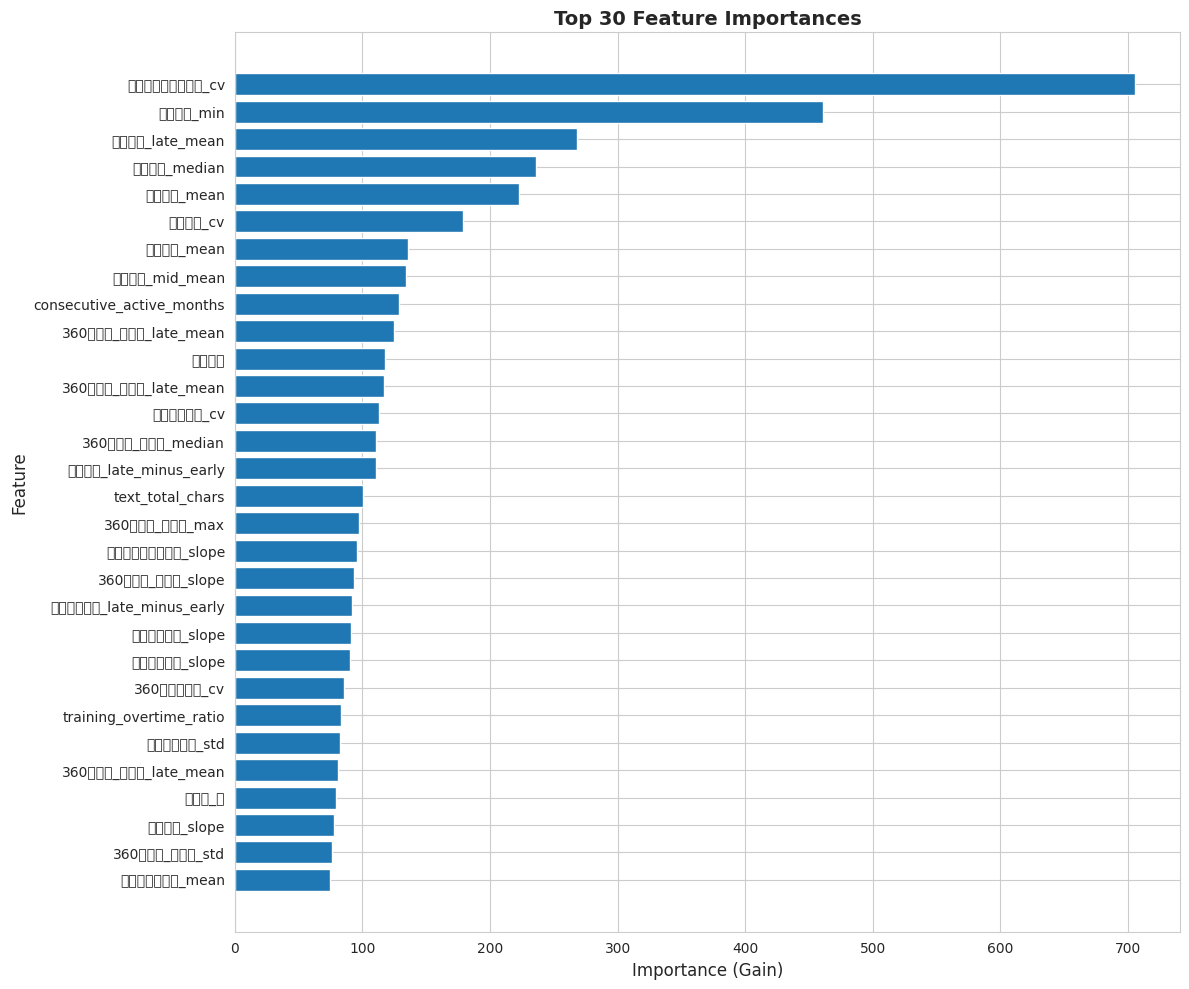

In [21]:
# Top 30特徴量を可視化
top_n = 30
top_features = feature_importance_agg.head(top_n)

plt.figure(figsize=(12, 10))
plt.barh(range(len(top_features)), top_features['mean'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance (Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# 提出ファイル作成
sub = pd.DataFrame({ID_COL: test_ids, TARGET_COL: result_data["test_preds"]})

sub.to_csv(SUBMISSION_PATH, index=False,header=False)
logger.info(f"提出ファイルを保存しました: {SUBMISSION_PATH}")
logger.info("=== 実験完了 ===")

print(f"\n提出ファイル: {SUBMISSION_PATH}")
print(f"CV Score (LogLoss): {lgb_cv:.4f}")

[2026-08-05 16:04:49] [INFO] 提出ファイルを保存しました: /content/drive/MyDrive/jaggle_2026/data/output/20260805/20260805_05_baseline_lgbm_feature_engineering.csv


INFO:05_baseline_lgbm_feature_engineering:提出ファイルを保存しました: /content/drive/MyDrive/jaggle_2026/data/output/20260805/20260805_05_baseline_lgbm_feature_engineering.csv


[2026-08-05 16:04:49] [INFO] === 実験完了 ===


INFO:05_baseline_lgbm_feature_engineering:=== 実験完了 ===



提出ファイル: /content/drive/MyDrive/jaggle_2026/data/output/20260805/20260805_05_baseline_lgbm_feature_engineering.csv
CV Score (LogLoss): 0.5919


## 🎉 完了

このノートブックでは、EDAレポートで提案された全ての特徴量エンジニアリング手法を実装しました：

1. ✅ **月次データの集約特徴量** - 統計量、時期別、トレンド
2. ✅ **月次カテゴリカル変数の変化** - 異動、変更パターン
3. ✅ **欠損値特徴量** - 欠損率、最初の記録、連続欠損
4. ✅ **ドメイン知識特徴量** - HR指標（エンゲージメント、ワークライフバランスなど）
5. ✅ **テキスト特徴量** - 文字数統計
6. ✅ **時間的特徴量** - 入社年月、四半期、年度
7. ✅ **交互作用特徴量** - 年齢×経験、給与×等級
8. ✅ **カテゴリカル変数の処理** - Label/Ordinal Encoding
9. ✅ **TimeSeriesSplitでのモデル学習** - lgbm_model_v2.py使用
10. ✅ **特徴量重要度分析**

### 次のステップ

- 🔹 TF-IDF特徴量の追加
- 🔹 Target Encodingの実装（CVでリーク防止）
- 🔹 ハイパーパラメータチューニング（Optuna）
- 🔹 他のモデル（XGBoost, CatBoost）とのアンサンブル
- 🔹 特徴量選択と正則化